# Text Analytics
## Assignment on MLP

- Georgios Boufis, *f3352504*, *geo.boufis@aueb.gr*
- Leonidha Mara, *f3352514*, *leo.mara@aueb.gr*

In [4]:
# Installing wget to download files and gensim for word embeddings
!pip install --upgrade wget --quiet
! pip install gensim
!pip install torch

  Using cached torch-2.10.0-2-cp313-none-macosx_11_0_arm64.whl.metadata (31 kB)
Using cached torch-2.10.0-2-cp313-none-macosx_11_0_arm64.whl (79.5 MB)


In [2]:
%pip install --upgrade gensim numpy umap-learn matplotlib seaborn --quiet

Note: you may need to restart the kernel to use updated packages.


In [5]:
import numpy as np
import re
import string
import matplotlib.pyplot as plt

from sklearn.feature_extraction.text import CountVectorizer, TfidfVectorizer
from sklearn.decomposition import TruncatedSVD
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, TensorDataset
import gensim.downloader as api
import string
import nltk
from nltk.corpus import stopwords
from nltk.tokenize import sent_tokenize, word_tokenize
from tqdm import tqdm
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (
    f1_score,
    classification_report,
    average_precision_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    precision_recall_curve,
    auc
)
import matplotlib.pyplot as plt
import time


nltk.download('punkt')
nltk.download('punkt_tab')
nltk.download('stopwords')

[nltk_data] Downloading package punkt to
[nltk_data]     /Users/giorgosboufis/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt.zip.
[nltk_data] Downloading package punkt_tab to
[nltk_data]     /Users/giorgosboufis/nltk_data...
[nltk_data]   Unzipping tokenizers/punkt_tab.zip.
[nltk_data] Downloading package stopwords to
[nltk_data]     /Users/giorgosboufis/nltk_data...
[nltk_data]   Unzipping corpora/stopwords.zip.


True

In [6]:
device = torch.device('cuda') if torch.cuda.is_available() else torch.device('cpu')
print(f"Using device: {device}")

Using device: cpu


**Dataset Loading and Exploration**
We are using the IMDb Movie Reviews dataset for sentiment analysis. This code downloads the raw data, extracts it, and loads it into our environment.

In [7]:
# Downloading the aclImdb dataset from Stanford's server
import wget
url = "https://ai.stanford.edu/~amaas/data/sentiment/aclImdb_v1.tar.gz"
filename = wget.download(url)
print(filename)

aclImdb_v1.tar.gz


In [9]:
# Extracting the compressed tar file to access the review folders
%%capture
!tar xvzf aclImdb_v1.tar.gz

UsageError: Line magic function `%%capture` not found.


In [ ]:
# Loading the files from the 'neg' and 'pos' directories
from sklearn.datasets import load_files
from sklearn.model_selection import train_test_split

train = load_files("aclImdb/train", categories=['neg', 'pos'], encoding="utf-8")
test  = load_files("aclImdb/test",  categories=['neg', 'pos'], encoding="utf-8")

# Combining them to create a full dataset for custom splitting later
x = train.data + test.data
y = list(train.target) + list(test.target)


In [ ]:
print(train.target_names)

['neg', 'pos']


In [ ]:
# First sample and target
print(f'Sample: {x[1]} \nTarget: {y[1]}')

Sample: Words can't describe how bad this movie is. I can't explain it by writing only. You have too see it for yourself to get at grip of how horrible a movie really can be. Not that I recommend you to do that. There are so many clichés, mistakes (and all other negative things you can imagine) here that will just make you cry. To start with the technical first, there are a LOT of mistakes regarding the airplane. I won't list them here, but just mention the coloring of the plane. They didn't even manage to show an airliner in the colors of a fictional airline, but instead used a 747 painted in the original Boeing livery. Very bad. The plot is stupid and has been done many times before, only much, much better. There are so many ridiculous moments here that i lost count of it really early. Also, I was on the bad guys' side all the time in the movie, because the good guys were so stupid. "Executive Decision" should without a doubt be you're choice over this one, even the "Turbulence"-movi

**Data Visualization**

Total Dataset Size: We have a total of 50,000 reviews, which is a large enough sample to train a reliable model.

Perfect Balance: The dataset is perfectly split with 25,000 negative (50%) and 25,000 positive (50%) reviews. This is great because the model won't be biased toward one specific sentiment.

Review Length Variation: * Reviews vary a lot in size. The shortest is only 4 words, while the longest reaches 2,470 words.

Our mean is 231.2 words while the median is only 173.0. In a symmetrical distribution, these would be the same. Since the mean is significantly higher, it shows the average is being pulled to the right by very long reviews.

We have a maximum length of 2,470 words, which is huge compared to the median. These long reviews form the "long tail" on the right side of the histogram.

Most reviews are concentrated on the shorter end (near the 173-word mark), while the distribution stretches out much further toward the higher word counts.

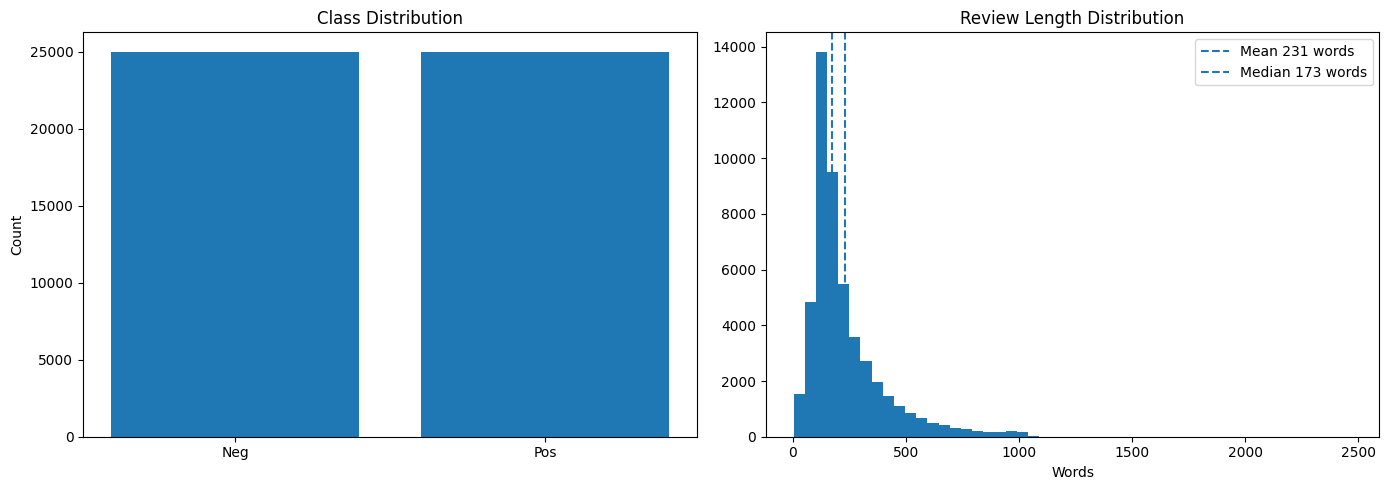


Total Reviews: 50000
Neg: 25000 (50.0%)
Pos: 25000 (50.0%)

Length stats:
Min: 4
Max: 2470
Mean: 231.2
Median: 173.0
Std: 171.3



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

# Visualizing how many reviews we have per class and their word counts
counts = np.bincount(y)
lengths = [len(r.split()) for r in x]

fig, ax = plt.subplots(1, 2, figsize=(14, 5))

# Class distribution
ax[0].bar(range(len(counts)), counts)
ax[0].set_xticks(range(len(counts)))
ax[0].set_xticklabels(['Neg', 'Pos'])
ax[0].set_title("Class Distribution")
ax[0].set_ylabel("Count")

# Review length distribution
ax[1].hist(lengths, bins=50)
ax[1].axvline(np.mean(lengths), linestyle="--", label=f"Mean {np.mean(lengths):.0f} words")
ax[1].axvline(np.median(lengths), linestyle="--", label=f"Median {np.median(lengths):.0f} words")
ax[1].set_title("Review Length Distribution")
ax[1].set_xlabel("Words")
ax[1].legend()

plt.tight_layout()
plt.show()

print(f"""
Total Reviews: {len(x)}
Neg: {counts[0]} ({counts[0]/len(x)*100:.1f}%)
Pos: {counts[1]} ({counts[1]/len(x)*100:.1f}%)

Length stats:
Min: {min(lengths)}
Max: {max(lengths)}
Mean: {np.mean(lengths):.1f}
Median: {np.median(lengths):.1f}
Std: {np.std(lengths):.1f}
""")

**Data Splitting**

Before we start the preprocessing, we need to divide our 50,000 reviews into different sets. This ensures we can train the model on one portion of data and then fairly test it on data it hasn't seen before.

Train (36,000 samples): This is the largest part of the data that the model uses to learn patterns and associations between words and sentiment.

Validation (9,000 samples): We use this "dev" set to check the model's performance during training and make adjustments to things like learning rates or layer sizes.

Test (5,000 samples): This is our "final exam." It remains untouched until the very end so we can get an unbiased evaluation of how the model works in the real world.

By splitting the data this way,we try to  prevent overfitting, which happens when a model just memorizes the training data instead of actually learning how to read sentiment.

In [ ]:
# First, we split the total data: 90% stays for training/validation and 10% is set aside for the final test
X_temp, X_test, y_temp, y_test = train_test_split(
    x, y, test_size=0.1,
    random_state=42
)

# Then, we take that 90% (X_temp) and split it again:
# 80% for the actual training and 20% for validation (tuning)
X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.2,
    #stratify=y_temp,
    random_state=42
)

# Printing the final sizes to confirm the split worked
print(f"train: {len(X_train)}, val: {len(X_val)}, test: {len(X_test)}")

train: 36000, val: 9000, test: 5000


**Text Cleaning and Tokenization**

we need a function to clean it up and break it into individual words (tokens) that a machine can process.

**Noise Removal**: It filters out symbols like @, #, and * which are common in online reviews but don't carry emotional meaning.

**Vocabulary Reduction**: By removing "stopwords" (like "the", "and", "in"), we focus only on the descriptive words that actually indicate if a review is positive or negative.

**Normalization**: Converting everything to lowercase ensures that the model treats "Amazing", "AMAZING", and "amazing" as the exact same word.

**Granularity**: We go from a giant block of text to a clean list of meaningful words, making it much easier to count frequencies or create embeddings in the next steps.

In [ ]:
def tokenize(data):
  # We load the standard English stopwords list and add our own
  # common words and punctuation to ignore
  stop_words = stopwords.words('english')
  stop_words.extend(string.punctuation)
  stop_words.extend(["the", "of", "and", "as", "a", "to", "in", "on", "for"])

  tokenized_samples = []
  for sample in data:
    tokens = []
    # Split text into sentences
    sentences = sent_tokenize(sample)
    for sent in sentences:
        # Tokenize each sentence into words
        words = word_tokenize(sent)
        for word in words:
            # Filter out stopwords and unwanted tokens
            if '\n' in word or "\t" in word or "--" in word or "*" in word or "@" in word or "#" in word or word.lower() in stop_words:
                continue
            if word.strip():
                # Process the token and add to list
                tokens.append(word.replace('"', "'").strip().lower())
    tokenized_samples.append(tokens)

  return tokenized_samples

We make sure that all our data (Train, Val, and Test) is processed in the exact same way. By tokenizing once and saving the results into these variables, we don't have to keep re-processing the raw text every time we want to try a different model. This is the final "text-only" step. After this, the words will be transformed into numbers using TF-IDF or Word-Embeddings


In [ ]:
# Running the cleaning function on the training set
X_train_tokenized = tokenize(X_train)

# Doing the same for the validation set
X_val_tokenized = tokenize(X_val)

# Cleaning the test set
X_test_tokenized = tokenize(X_test)

In [ ]:
# We download a pre-trained model from Google News that knows the 'meaning' of 3 million words
word_vectors = api.load("word2vec-google-news-300")

[==================================================] 100.0% 1662.8/1662.8MB downloaded


**Feature Extraction Function**

Since machine learning models can’t understand words directly, we need a way to turn our tokenized lists into numerical vectors. This function is flexible and allows us to choose between two different ways of representing text: TF-IDF or Word Embeddings.

**TF-IDF Logic**: It treats text as a "bag of words" and counts them, but it gives more weight to unique, meaningful words and less to common ones.

**Word2Vec Centroids**: Instead of just counting, this uses 300-dimensional vectors that capture the semantic relationship between words (e.g., "king" and "queen" are close together). By averaging them, we get a single vector that represents the general "vibe" of the movie review.

**Feature Reduction**: Using Truncated SVD helps us if we have too many features (like 20,000 TF-IDF terms), making the training of our later models much faster.



In [ ]:
def preprocess_data(X_train_tokenized,
                    X_val_tokenized,
                    X_test_tokenized,
                    y_train,
                    y_val,
                    y_test,
                    representation = 'tfidf',
                    features_number = 20000,
                    reduce_features = False,
                    reduced_features_number = None):
  # TF-IDF (Term Frequency-Inverse Document Frequency)
  if representation == "tfidf":
    # We use TfidfVectorizer to highlight important words that appear frequently
    # in a review but not across the entire dataset
    vectorizer = TfidfVectorizer(max_features = features_number,
                                 sublinear_tf = True)

    # We 'fit' on the training data and 'transform' all sets into numerical arrays
    X_train_tfidf = vectorizer.fit_transform(
        [" ".join(x) for x in X_train_tokenized]
    ).toarray()
    X_val_tfidf = vectorizer.transform(
        [" ".join(x) for x in X_val_tokenized]
    ).toarray()
    X_test_tfidf = vectorizer.transform(
        [" ".join(x) for x in X_test_tokenized]
    ).toarray()

  # Pre-trained Word2Vec Embeddings
  elif representation == "embeddings":

    X_train_tfidf, X_val_tfidf, X_test_tfidf = [], [], []

    # For every review, we find the vector for each word and calculate the 'centroid' (the average)
    for doc in X_train_tokenized:
      embeddings = [word_vectors[word]
                    for word in doc if word in word_vectors]
      if embeddings:
        centroid = np.mean(embeddings, axis = 0)
      else:
        centroid = np.zeros(word_vectors.vector_size) # Handling empty reviews
      X_train_tfidf.append(centroid)
    X_train_tfidf = np.array(X_train_tfidf)

    for doc in X_val_tokenized:
      embeddings = [word_vectors[word]
                  for word in doc if word in word_vectors]
      if embeddings:
        centroid = np.mean(embeddings, axis = 0)
      else:
        centroid = np.zeros(word_vectors.vector_size)
      X_val_tfidf.append(centroid)
    X_val_tfidf = np.array(X_val_tfidf)


    for doc in X_test_tokenized:
      embeddings = [word_vectors[word]
                    for word in doc if word in word_vectors]
      if embeddings:
        centroid = np.mean(embeddings, axis = 0)
      else:
        centroid = np.zeros(word_vectors.vector_size)
      X_test_tfidf.append(centroid)
    X_test_tfidf = np.array(X_test_tfidf)


  else:
    raise ValueError("representation must be 'tfidf' or 'embeddings'")

  # Dimensionality Reduction
  if reduce_features:
    # If our vectors are too large, we use SVD to compress them into a smaller,
    # more manageable size while keeping the most important info
    assert reduced_features_number is not None
    svd = TruncatedSVD(n_components = reduced_features_number,
                       random_state = 42)
    X_train_tfidf = svd.fit_transform(X_train_tfidf)
    X_val_tfidf = svd.transform(X_val_tfidf)
    X_test_tfidf = svd.transform(X_test_tfidf)

  return (X_train_tfidf, y_train), (X_val_tfidf, y_val), (X_test_tfidf, y_test)


**Majority Baseline**

In the training set, there are 18,045 positive reviews and 17,955 negative ones. Since positive is the majority, the model decided to predict "Positive" (Class 1) for every single review it sees from now on.

We get an accuracy of roughly 50% (specifically 0.4994 on the test set). This makes sense because the dataset is balanced; if you guess the same thing every time, you'll be right half the time.

For Class 1 (Positive), the Recall is 1.0000 because the model correctly found all the positive reviews. However, the Precision is only ~0.50, because half of its positive guesses were actually negative reviews.

For Class 0 (Negative), the Recall and Precision are 0.0000 because the model never guessed "negative" even once.





In [ ]:

from sklearn.dummy import DummyClassifier
from sklearn.metrics import accuracy_score, ConfusionMatrixDisplay, classification_report, average_precision_score
import time

# We prepare the data using only 500 TF-IDF features for this quick baseline test
(X_train_tfidf, y_train), (X_val_tfidf, y_val), (X_test_tfidf, y_test) = preprocess_data(
    X_train_tokenized, X_val_tokenized, X_test_tokenized, y_train, y_val, y_test, representation='tfidf', features_number=500
)

# Converting labels to numpy arrays for easier calculations
y_train = np.array(y_train)
y_val   = np.array(y_val)
y_test = np.array(y_test)

# Train baseline model
# The dummy classifier always predicts the most frequent class
baseline = DummyClassifier(strategy='most_frequent')

start_time = time.time()
baseline.fit(X_train_tfidf, y_train)
print(f"Training took: {time.time() - start_time:.4f} seconds \n")

# A function to calculate Precision, Recall, F1-Score, and PR-AUC
def eval_baseline(name, model, X, y):
    y_pred = model.predict(X)

    # per-class + macro precision/recall/f1
    report = classification_report(y, y_pred, output_dict=True, zero_division=0)

    # PR-AUC (Average Precision) needs scores/probabilities
    # For binary classification: use prob of class 1
    if hasattr(model, "predict_proba"):
        y_score = model.predict_proba(X)[:, 1]
        pr_auc_pos = average_precision_score(y, y_score)  # AP for positive class (class 1)

        # "per-class PR-AUC": for class 0, invert labels and use prob of class 0
        y_score0 = model.predict_proba(X)[:, 0]
        pr_auc_neg = average_precision_score(1 - y, y_score0)

        pr_auc_macro = 0.5 * (pr_auc_pos + pr_auc_neg)
    else:
        pr_auc_pos = pr_auc_neg = pr_auc_macro = np.nan

    print(f"--- {name} ---")
    print(f"Class 0: P={report['0']['precision']:.4f}, R={report['0']['recall']:.4f}, F1={report['0']['f1-score']:.4f}, PR-AUC={pr_auc_neg:.4f}")
    print(f"Class 1: P={report['1']['precision']:.4f}, R={report['1']['recall']:.4f}, F1={report['1']['f1-score']:.4f}, PR-AUC={pr_auc_pos:.4f}")
    print(f"Macro : P={report['macro avg']['precision']:.4f}, R={report['macro avg']['recall']:.4f}, F1={report['macro avg']['f1-score']:.4f}, PR-AUC={pr_auc_macro:.4f}")
    print(f"Acc   : {report['accuracy']:.4f}\n")

    return {
        "per_class": report,
        "pr_auc": {"class0": pr_auc_neg, "class1": pr_auc_pos, "macro": pr_auc_macro}
    }

print("#Class 0 in Train:", (y_train == 0).sum())
print("#Class 1 in Train:", (y_train == 1).sum(), "\n")

# Running evaluation on all three data splits
train_res = eval_baseline("Majority baseline (TRAIN)", baseline, X_train_tfidf, y_train)
val_res   = eval_baseline("Majority baseline (DEV)",   baseline, X_val_tfidf,   y_val)
test_res  = eval_baseline("Majority baseline (TEST)",  baseline, X_test_tfidf,  y_test)





Training took: 0.0045 seconds 

#Class 0 in Train: 17955
#Class 1 in Train: 18045 

--- Majority baseline (TRAIN) ---
Class 0: P=0.0000, R=0.0000, F1=0.0000, PR-AUC=0.4988
Class 1: P=0.5012, R=1.0000, F1=0.6678, PR-AUC=0.5012
Macro : P=0.2506, R=0.5000, F1=0.3339, PR-AUC=0.5000
Acc   : 0.5012

--- Majority baseline (DEV) ---
Class 0: P=0.0000, R=0.0000, F1=0.0000, PR-AUC=0.5047
Class 1: P=0.4953, R=1.0000, F1=0.6625, PR-AUC=0.4953
Macro : P=0.2477, R=0.5000, F1=0.3313, PR-AUC=0.5000
Acc   : 0.4953

--- Majority baseline (TEST) ---
Class 0: P=0.0000, R=0.0000, F1=0.0000, PR-AUC=0.5006
Class 1: P=0.4994, R=1.0000, F1=0.6661, PR-AUC=0.4994
Macro : P=0.2497, R=0.5000, F1=0.3331, PR-AUC=0.5000
Acc   : 0.4994



**Visualizing the Baseline Results**

To better understand why our baseline got the scores it did, we visualize its predictions using Confusion Matrices. These matrices show exactly where the model is making mistakes by comparing the "True" labels with the "Predicted" ones.

In all three plots, the entire left column (Class 0) is empty (0), while the entire right column (Class 1) is filled with numbers. This confirms that our baseline is simply ignoring the "Negative" class and predicting "Positive" for everything.

In the train set, the model predicts Class 1 for all 36,000 samples. It correctly gets 18,045 right (True Positives) but misses all 17,955 negative reviews (False Positives).

In the test set, out of 5,000 reviews, the model predicts "Positive" for all of them. Since the test set is also balanced, it gets 2,497 right and 2,503 wrong.

As a result, these matrices prove that the model has zero discriminative power. It doesn't look at the text at all, it just plays the numbers game based on the training majority.

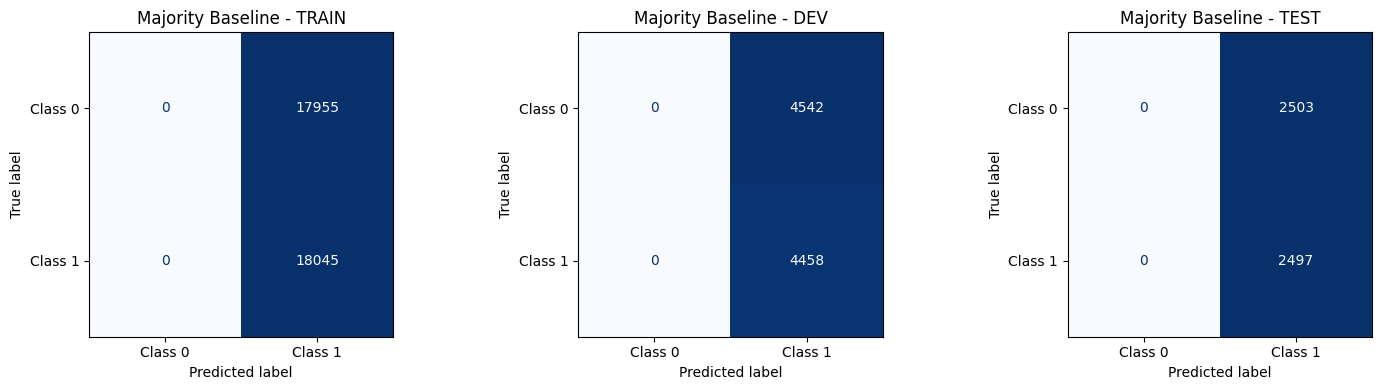


Confusion Matrix (TRAIN):
[[    0 17955]
 [    0 18045]]

Confusion Matrix (DEV):
[[   0 4542]
 [   0 4458]]

Confusion Matrix (TEST):
[[   0 2503]
 [   0 2497]]


In [ ]:
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# Predictions για κάθε set
y_train_pred = baseline.predict(X_train_tfidf)
y_val_pred = baseline.predict(X_val_tfidf)
y_test_pred = baseline.predict(X_test_tfidf)

# Create confusion matrices
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train
cm_train = confusion_matrix(y_train, y_train_pred)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Class 0', 'Class 1'])
disp_train.plot(ax=axes[0], cmap='Blues', colorbar=False)
axes[0].set_title('Majority Baseline - TRAIN')

# Validation
cm_val = confusion_matrix(y_val, y_val_pred)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Class 0', 'Class 1'])
disp_val.plot(ax=axes[1], cmap='Blues', colorbar=False)
axes[1].set_title('Majority Baseline - DEV')

# Test
cm_test = confusion_matrix(y_test, y_test_pred)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Class 0', 'Class 1'])
disp_test.plot(ax=axes[2], cmap='Blues', colorbar=False)
axes[2].set_title('Majority Baseline - TEST')

plt.tight_layout()
plt.show()

# Print confusion matrices as numbers
print("\nConfusion Matrix (TRAIN):")
print(cm_train)
print("\nConfusion Matrix (DEV):")
print(cm_val)
print("\nConfusion Matrix (TEST):")
print(cm_test)

**Logistic Regression**

We configure a linear classifier using standard settings, such as the $L_2$ penalty to keep the weights small and the $C=1.0$ parameter to balance the training error against regularization. The model "fits" to the training data, meaning it learns which words in our TF-IDF representation are most strongly associated with positive or negative sentiment.

In [ ]:
# ==================== TRAIN MODEL ====================
# We initialize the Logistic Regression model
# 'liblinear' is a reliable solver for this type of classification
# 'l2' penalty (Ridge regularization) helps prevent the model from overfitting
clf_lr = LogisticRegression(
    solver="liblinear",
    penalty="l2",
    C=1.0,
    random_state=42,
    max_iter=2000
)

# We record the time to see how long the learning process takes
start_time = time.time()

# Training (fitting) the model using our processed training data
clf_lr.fit(X_train_tfidf, y_train)

# Printing the total duration of the training phase
print(f"Training took: {time.time() - start_time:.4f} seconds\n")


Training took: 1.2539 seconds



**Defining the Evaluation Function**

nstead of manually calculating scores for every experiment, we create a reusable function called eval_lr. This function gives us a complete report card for our Logistic Regression model by looking at its performance from multiple angles.

Precision: Tells us how many of the reviews the model labeled as Positive were actually positive.

Recall: Tells us what percentage of the actual positive reviews the model managed to find.

F1-Score: This is the harmonic mean of Precision and Recall. It’s the best way to see the overall quality of the model, especially if we want to avoid both False Positives and False Negatives.

PR-AUC (Precision-Recall Area Under Curve): This is a more advanced metric that looks at the model's performance across all possible confidence thresholds. A high PR-AUC means the model is very good at distinguishing between classes even when it's not 100% sure.

In [ ]:
# ==================== EVALUATION FUNCTION ====================
def eval_lr(name, model, X, y):
    # First, we use the model to predict the labels for our data
    y_pred = model.predict(X)

    # We generate a standard classification report which includes
    # Precision, Recall, and F1-score for each class
    report = classification_report(y, y_pred, output_dict=True, zero_division=0)
    # We check if the model can provide probability scores
    if hasattr(model, "predict_proba"):
        # Probabilities for the Positive class (1)
        y_score = model.predict_proba(X)[:, 1]
        pr_auc_pos = average_precision_score(y, y_score)

        # Probabilities for the Negative class
        y_score0 = model.predict_proba(X)[:, 0]
        pr_auc_neg = average_precision_score(1 - y, y_score0)

        # The Macro PR-AUC gives us the average performance across both classes
        pr_auc_macro = 0.5 * (pr_auc_pos + pr_auc_neg)
    else:
        # If the model doesn't support probabilities, we set these to "Not a Number"
        pr_auc_pos = pr_auc_neg = pr_auc_macro = np.nan

    # We also calculate the Micro and Macro F1 scores to see how
    # well the model balances precision and recall
    f1_micro = f1_score(y, y_pred, average = 'micro')
    f1_macro = f1_score(y, y_pred, average = 'macro')

    # Printing a clean summary of all the metrics
    print(f"--- {name} ---")
    print(f"Class 0: P={report['0']['precision']:.4f}, R={report['0']['recall']:.4f}, F1={report['0']['f1-score']:.4f}, PR-AUC={pr_auc_neg:.4f}")
    print(f"Class 1: P={report['1']['precision']:.4f}, R={report['1']['recall']:.4f}, F1={report['1']['f1-score']:.4f}, PR-AUC={pr_auc_pos:.4f}")
    print(f"Macro : P={report['macro avg']['precision']:.4f}, R={report['macro avg']['recall']:.4f}, F1={report['macro avg']['f1-score']:.4f}, PR-AUC={pr_auc_macro:.4f}")
    print(f"Micro F1: {f1_micro:.4f}")
    print(f"Acc   : {report['accuracy']:.4f}\n")


    # We return everything in a dictionary so we can save the results for later comparison

    return {
        "per_class" : report,
        "pr_auc" : {"class0" : pr_auc_neg, "class1" : pr_auc_pos, "macro" : pr_auc_macro},
        "f1_micro" : f1_micro,
        "f1_macro" : f1_macro
    }

**Results and Evaluation**

Compared to our 50% accuracy baseline, the Logistic Regression model is performing much better, reaching about 84.4% accuracy on the test set.

The performance is very consistent across all sets (85% on Train, 84% on Dev, and 84.4% on Test). This is a great sign because it means the model isn't just memorizing the training data; it has actually learned patterns that work on new, unseen reviews.

Both classes (Negative and Positive) have very similar F1-scores (around 0.84). This tells us the model is equally good at identifying both happy and unhappy customers.

The PR-AUC is around 0.92, which is very high. This means that when the model assigns a probability to a review, it’s usually correct in its ranking of which reviews are "more positive" than others.

In [ ]:
# ==================== EVALUATE ====================
train_res_lr = eval_lr("Logistic Regression (TRAIN)", clf_lr, X_train_tfidf, y_train)
val_res_lr = eval_lr("Logistic Regression (DEV)", clf_lr, X_val_tfidf, y_val)
test_res_lr = eval_lr("Logistic Regression (TEST)", clf_lr, X_test_tfidf, y_test)


--- Logistic Regression (TRAIN) ---
Class 0: P=0.8583, R=0.8388, F1=0.8485, PR-AUC=0.9302
Class 1: P=0.8432, R=0.8622, F1=0.8526, PR-AUC=0.9250
Macro : P=0.8507, R=0.8505, F1=0.8505, PR-AUC=0.9276
Micro F1: 0.8506
Acc   : 0.8506

--- Logistic Regression (DEV) ---
Class 0: P=0.8478, R=0.8342, F1=0.8410, PR-AUC=0.9240
Class 1: P=0.8338, R=0.8475, F1=0.8406, PR-AUC=0.9140
Macro : P=0.8408, R=0.8408, F1=0.8408, PR-AUC=0.9190
Micro F1: 0.8408
Acc   : 0.8408

--- Logistic Regression (TEST) ---
Class 0: P=0.8495, R=0.8366, F1=0.8430, PR-AUC=0.9262
Class 1: P=0.8387, R=0.8514, F1=0.8450, PR-AUC=0.9223
Macro : P=0.8441, R=0.8440, F1=0.8440, PR-AUC=0.9243
Micro F1: 0.8440
Acc   : 0.8440



**Visualizing Logistic Regression Performance**

Unlike the baseline that only predicted one class, these matrices show high numbers in the top-left (True Negatives) and bottom-right (True Positives) squares. This confirms the model is actually distinguishing between the two sentiments.

On our 5,000 test samples, the model correctly identified 2,094 negative and 2,126 positive reviews.

The model made 409 errors by labeling negative reviews as positive, and 371 errors by labeling positive reviews as negative. The fact that these error rates are similar shows that the model doesn't have a strong bias toward one class over the other.



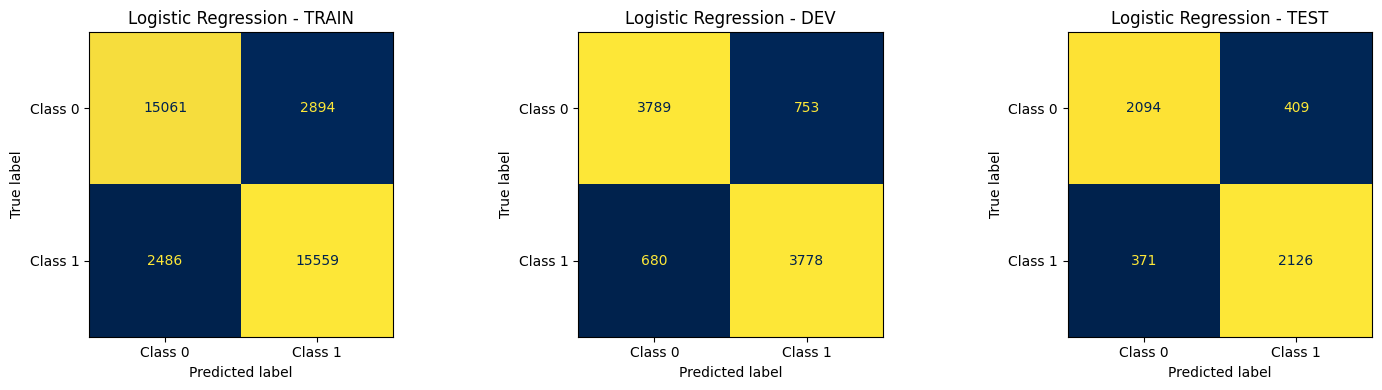


Confusion Matrix (TRAIN):
[[15061  2894]
 [ 2486 15559]]

Confusion Matrix (DEV):
[[3789  753]
 [ 680 3778]]

Confusion Matrix (TEST):
[[2094  409]
 [ 371 2126]]


In [ ]:
# ==================== CONFUSION MATRICES ====================
y_train_pred_lr = clf_lr.predict(X_train_tfidf)
y_val_pred_lr = clf_lr.predict(X_val_tfidf)
y_test_pred_lr = clf_lr.predict(X_test_tfidf)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train
cm_train = confusion_matrix(y_train, y_train_pred_lr)
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Class 0', 'Class 1'])
disp_train.plot(ax=axes[0], cmap='cividis', colorbar=False)
axes[0].set_title('Logistic Regression - TRAIN')

# Validation
cm_val = confusion_matrix(y_val, y_val_pred_lr)
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Class 0', 'Class 1'])
disp_val.plot(ax=axes[1], cmap='cividis', colorbar=False)
axes[1].set_title('Logistic Regression - DEV')

# Test
cm_test = confusion_matrix(y_test, y_test_pred_lr)
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Class 0', 'Class 1'])
disp_test.plot(ax=axes[2], cmap='cividis', colorbar=False)
axes[2].set_title('Logistic Regression - TEST')

plt.tight_layout()
plt.show()

print("\nConfusion Matrix (TRAIN):")
print(cm_train)
print("\nConfusion Matrix (DEV):")
print(cm_val)
print("\nConfusion Matrix (TEST):")
print(cm_test)

**ROC Curve**

The blue line bows significantly toward the top-left corner. This is exactly what we want to see—it means the model achieves a high True Positive Rate while maintaining a low False Positive Rate.

The Area Under the Curve (AUC) is 0.9240. If we picked one random positive review and one random negative review, there is a 92.4% chance the model would correctly rank the positive one higher.

Our curve is far above the dashed black line (the random baseline). This proves our Logistic Regression model is highly effective at distinguishing sentiment.

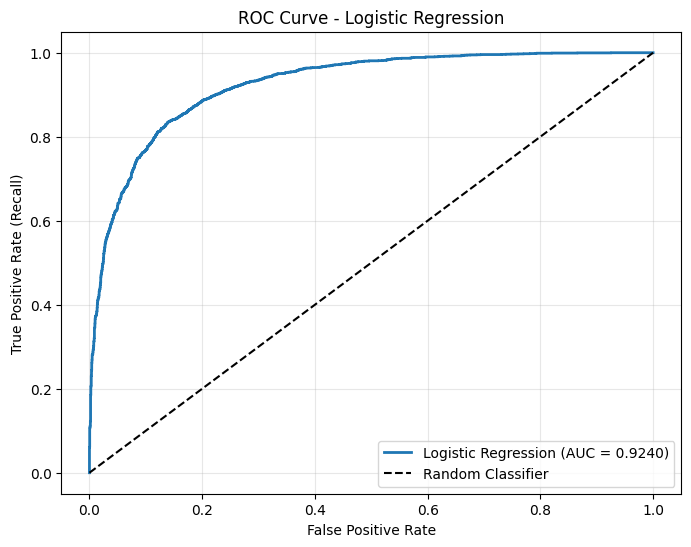

In [ ]:
# ==================== ROC CURVE ====================
y_scores_test = clf_lr.predict_proba(X_test_tfidf)[:, 1]
fpr, tpr, thresholds = roc_curve(y_test, y_scores_test)
auc_score = roc_auc_score(y_test, y_scores_test)

plt.figure(figsize=(8, 6))
plt.plot(fpr, tpr, label=f'Logistic Regression (AUC = {auc_score:.4f})', linewidth=2)
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title('ROC Curve - Logistic Regression')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**Precision-Recall Curve**

It shows the balance between being accurate (Precision) and finding all the relevant cases (Recall).

The curve stays very high (near 1.0 Precision) even as Recall increases. This means the model can identify a large portion of the positive reviews (high Recall) without making many mistakes (high Precision).

The area under this curve is 0.9223. This high score confirms that our model is very robust, it doesn't just guess correctly by chance, but maintains high quality across various strictness levels.

We can see that as we try to catch 100% of the positive reviews (Recall = 1.0), the Precision starts to drop. This is the classic trade-off  to find every single positive review, the model eventually has to lower its standards and might start misclassifying some negative reviews as positive.

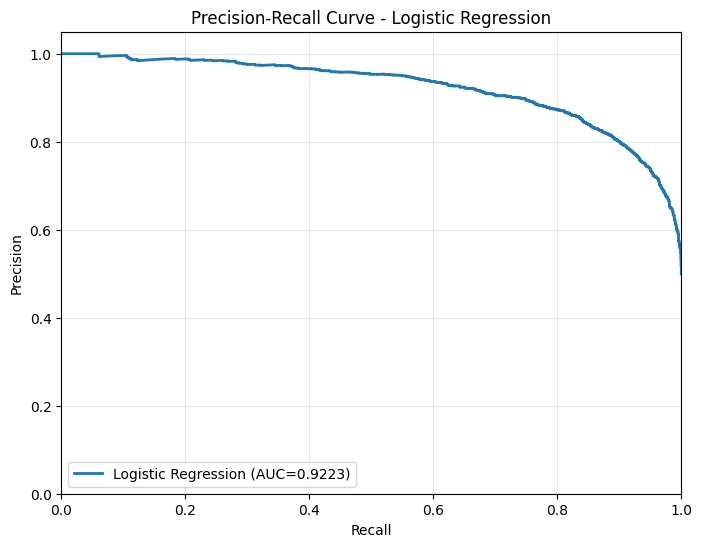

In [ ]:
# ==================== PRECISION-RECALL CURVE ====================
precision, recall, _ = precision_recall_curve(y_test, y_scores_test)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Logistic Regression (AUC={pr_auc:.4f})', linewidth=2)
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title('Precision-Recall Curve - Logistic Regression')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

## Define MLP model

We can use this same class to create a simple linear model (with no hidden layers) or a deep neural network just by changing the input list.

**ReLU Activation**: This is crucial because it allows the model to learn more than just simple linear relationships between words and sentiment.

By including **Dropout**, we force the model to be more robust and not rely too heavily on specific "noise" in the training data.

Adding **BatchNorm** or **LayerNorm** helps the model converge faster, which is very useful when we start training on thousands of reviews.

In [ ]:
# 2. Define a single parameterized model class
class CustomModel(nn.Module):
    def __init__(self, input_dim, hidden_layers=None,
                 dropout=0.0, batch_norm=False, layer_norm=False,
                 classes_number=2):
        super(CustomModel, self).__init__()
        layers = []
        prev_dim = input_dim

        if dropout > 0 and hidden_layers:
            layers.append(nn.Dropout(dropout))

        if hidden_layers:
            for hidden_dim in hidden_layers:
                layers.append(nn.Linear(prev_dim, hidden_dim))
                layers.append(nn.ReLU())
                if batch_norm:
                    layers.append(nn.BatchNorm1d(hidden_dim))
                if layer_norm:
                    layers.append(nn.LayerNorm(hidden_dim))
                if dropout > 0:
                    layers.append(nn.Dropout(dropout))
                prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, classes_number))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)

## Training and Evaluation scripts


**Training Function**:
This function handles the heavy lifting of teaching the model. It includes features like Early Stopping and a Learning Rate Scheduler to make sure we get the best possible results without wasting time.

**Evaluation Function**:
This function takes the trained model and tests it on a dataset (like the Test set). It calculates all the same metrics we used for Logistic Regression so we can compare them fairly.

We use DataLoader to feed the model small batches of reviews at a time. This is more memory-efficient than trying to process 36,000 reviews all at once.

By using the ReduceLROnPlateau scheduler, we ensure the model starts learning fast but slows down as it gets closer to the optimal solution to avoid overshooting.

The Early Stopping logic is a huge safety net. It stops the training as soon as the model starts "memorizing" the training set instead of learning general patterns.

In [ ]:
import copy
import os

# ==================== TRAINING FUNCTION ====================

def train_model(model, train_loader, val_loader, criterion, optimizer,
                epochs=20, patience=5, save_path=None):

    # The scheduler lowers the learning rate if the validation loss stops improving
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', factor=0.5, patience=3, min_lr=1e-6
    )

    train_losses, val_losses = [], []
    best_val_loss = float('inf')
    best_state_dict = None
    best_epoch = 0
    wait = 0  # initialize before loop

    for epoch in range(epochs):
        # Set the model to training mode (enables things like Dropout)
        model.train()
        train_loss = 0.0
        for X_batch, y_batch in train_loader:
            optimizer.zero_grad() # Reset gradients for each batch
            y_pred = model(X_batch) # Forward pass: get predictions
            loss = criterion(y_pred, y_batch) # Calculate the error
            loss.backward() # Backward pass: calculate how to adjust weights
            optimizer.step() # Update weights
            train_loss += loss.item()

        train_loss /= len(train_loader)
        train_losses.append(train_loss)

        # Set the model to evaluation mode
        model.eval()
        val_loss = 0.0
        with torch.no_grad(): # No need to calculate gradients here
            for X_batch, y_batch in val_loader:
                y_pred = model(X_batch)
                loss = criterion(y_pred, y_batch)
                val_loss += loss.item()

        val_loss /= len(val_loader)
        val_losses.append(val_loss)

        if epoch % 5 == 0 or epoch == epochs - 1:
            current_lr = optimizer.param_groups[0]['lr']
            print(f"Epoch: {epoch+1:3d}/{epochs} | Train Loss: {train_loss:.5f} | Val Loss: {val_loss:.5f}")
            print(f"Epoch {epoch+1}: LR={current_lr:.6f}")

        # Update the learning rate based on current performance
        scheduler.step(val_loss)

        # Early Stopping: Save the best version of the model and stop if it gets worse
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_epoch = epoch + 1
            best_state_dict = copy.deepcopy(model.state_dict())
            wait = 0
            if save_path is not None:
                torch.save(best_state_dict, save_path)
        else:
            wait += 1
            if wait >= patience:
                print(f"Early stopping at epoch {epoch+1}")
                break

    # We return the best version of the model found during training
    if best_state_dict is not None:
        model.load_state_dict(best_state_dict)

    return train_losses, val_losses, best_state_dict, best_epoch

# ==================== EVALUATION FUNCTION ====================

def evaluate_model(name, model, loader, y_true_np):
  model.eval() # Switch to eval mode (disables Dropout)
  y_score_list, y_pred_list = [], []

  with torch.no_grad():
      for X_batch, _ in loader:
        logits = model(X_batch) # Get raw model output
        probs = torch.softmax(logits, dim = 1) # Turn outputs into probabilities
        preds = torch.argmax(logits, dim = 1) # Pick the highest probability class

        y_pred_list.extend(preds.cpu().numpy())
        y_score_list.extend(probs.cpu().numpy())

  y_pred = np.array(y_pred_list)
  y_scores = np.array(y_score_list)

  # Calculate all performance metrics
  report = classification_report(y_true_np, y_pred, output_dict=True, zero_division=0)

  # PR-AUC
  y_score_pos = y_scores[:, 1]
  pr_auc_pos = average_precision_score(y_true_np, y_score_pos)

  y_score_neg = y_scores[:, 0]
  pr_auc_neg = average_precision_score(1 - y_true_np, y_score_neg)

  pr_auc_macro = 0.5 * (pr_auc_pos + pr_auc_neg)

  # F1 scores
  f1_micro = f1_score(y_true_np, y_pred, average='micro')
  f1_macro = f1_score(y_true_np, y_pred, average='macro')


  print(f"--- {name} ---")
  print(f"Class 0: P={report['0']['precision']:.4f}, R={report['0']['recall']:.4f}, F1={report['0']['f1-score']:.4f}, PR-AUC={pr_auc_neg:.4f}")
  print(f"Class 1: P={report['1']['precision']:.4f}, R={report['1']['recall']:.4f}, F1={report['1']['f1-score']:.4f}, PR-AUC={pr_auc_pos:.4f}")
  print(f"Macro : P={report['macro avg']['precision']:.4f}, R={report['macro avg']['recall']:.4f}, F1={report['macro avg']['f1-score']:.4f}, PR-AUC={pr_auc_macro:.4f}")
  print(f"Micro F1: {f1_micro:.4f}")
  print(f"Acc   : {report['accuracy']:.4f}\n")

  # Return a dictionary with all results and the actual predictions
  return {
        "per_class": report,
        "pr_auc": {"class0": pr_auc_neg, "class1": pr_auc_pos, "macro": pr_auc_macro},
        "f1_micro": f1_micro,
        "f1_macro": f1_macro,
        "y_pred": y_pred,
        "y_scores": y_scores
    }


**Hyperparameter Tuning and Model Selectiont**


**TF-IDF vs. Embeddings**: In this specific setup, TF-IDF  won. The best validation loss ($0.2716$) came from a TF-IDF model.

Our "Best Config" was the MLP with LayerNorm S (using TF-IDF). It only needed 64 hidden neurons to beat the deeper models.

If you look at the logs, the models with BatchNorm and LayerNorm usually started with a much lower loss right from Epoch 1 compared to the "Simple" or "Linear" models. They are much more stable.

he "Linear" baseline had a high loss (~0.63). Moving to an MLP with even one hidden layer dropped the loss significantly (to ~0.44 or lower). This shows that sentiment is "non-linear"—you need the complexity of a neural network to catch the nuances of a movie review.

Most models didn't actually reach 20 epochs. They stopped around epoch 7 to 13, which means our "Patience" setting saved us from wasting time on models that were starting to overfit.

In [ ]:
representations = {"TF-IDF": "tfidf", "Embeddings": "embeddings"}

# We test four different architectures: simple Linear, and MLPs with various normalization
CONFIGS = {
    # Configuration 1: Linear baseline
     "Linear":{  "hidden": [], "dropout": 0.0,
     "batch_norm": False, "layer_norm": False, "lr": 0.001, "batch_size": 128},

    # Configuration 2: Small MLP with dropout
     "MLP with Dropout s Batch":{"hidden": [64], "dropout": 0.4,
     "batch_norm": False, "layer_norm": False, "lr": 0.001, "batch_size": 128},

    # # Configuration 2: Small MLP with dropout
     "MLP with Dropout L Batch":{"hidden": [64], "dropout": 0.4,
      "batch_norm": False, "layer_norm": False, "lr": 0.005, "batch_size": 128},

    # Configuration 3: Larger window, deeper MLP
     "MLP with Dropout deep":{ "hidden": [128, 64], "dropout": 0.5,
     "batch_norm": False, "layer_norm": False, "lr": 0.001, "batch_size": 128},

    # Configuration 4: BatchNorm architecture
     "MLP with BatchNorm":{ "hidden": [128, 64], "dropout": 0.5,
     "batch_norm": True, "layer_norm": False, "lr": 0.001, "batch_size": 128},

    # Configuration 5: LayerNorm architecture
     "MLP with LayerNorm S":{  "hidden": [64], "dropout": 0.5,
     "batch_norm": False, "layer_norm": True, "lr": 0.001, "batch_size": 128},

    # Configuration 6:
    "MLP with LayerNorm L":{ "hidden": [128, 64], "dropout": 0.5,
     "batch_norm": False, "layer_norm": True, "lr": 0.0001, "batch_size": 128}
}


results = {}
best_overall = {
    "key": None,
    "val_loss": float("inf"),
    "state_dict": None,
    "rep_name": None,
    "rep_type": None,
    "model_name": None,
    "hidden_layers": None,
    "dropout": None,
    "lr": None,
    "best_epoch": None,

}

epochs = 20
patience = 5
batch_size = 128

# The TUNING LOOP: It iterates through every possible combination defined above
for rep_name, rep_type in representations.items():
    (X_train_tfidf, y_train), (X_val_tfidf, y_val), (X_test_tfidf, y_test) = preprocess_data(X_train_tokenized, X_val_tokenized, X_test_tokenized, y_train, y_val, y_test,  representation=rep_type, features_number = 5000)

    train_dataset = TensorDataset(torch.FloatTensor(X_train_tfidf).to(device),
                                  torch.LongTensor(y_train).to(device))
    val_dataset = TensorDataset(torch.FloatTensor(X_val_tfidf).to(device),
                                torch.LongTensor(y_val).to(device))
    test_dataset = TensorDataset(torch.FloatTensor(X_test_tfidf).to(device),
                                 torch.LongTensor(y_test).to(device))


    train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True)
    val_loader   = DataLoader(val_dataset,   batch_size=batch_size)
    test_loader  = DataLoader(test_dataset,  batch_size=batch_size)


    input_dim = X_train_tfidf.shape[1]
    num_classes = len(np.unique(y_train))

    for model_name, config in CONFIGS.items():
        model_key = f"{model_name} ({rep_name}) | layers = {config["hidden"]} | dropout = {config["dropout"]} | lr = {config["lr"]}"

        model = CustomModel(
            input_dim,
            hidden_layers = config["hidden"],
            dropout = config["dropout"],
            batch_norm = ("BatchNorm" in model_name),
            layer_norm = ("LayerNorm" in model_name),
            classes_number = num_classes
        ).float().to(device)


        criterion = nn.CrossEntropyLoss()
        optimizer = optim.Adam(model.parameters(), lr = config["lr"], weight_decay = 1e-2)

        total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
        print(f"Model: {model_name} | Total learnable parameters: {total_params:,}")

        print(f"\nTraining {model_key}...")

        # Training each specific model version
        train_losses, val_losses, best_state_dict, best_epoch = train_model(
            model, train_loader, val_loader, criterion, optimizer,
            epochs=epochs, patience=5, save_path=None
        )

        best_val_loss = float(np.min(val_losses))
        best_epoch = int(np.argmin(val_losses)) + 1

        results[model_key] = {
            "train_losses":  train_losses,
            "val_losses":    val_losses,
            "best_epoch":    best_epoch,
            "best_val_loss": best_val_loss,
            "rep":           rep_name,
            "model":         model_name,
            "hidden_layers": config["hidden"],
            "dropout":       config["dropout"],
            "lr":            config["lr"],
            "total_params": total_params,

        }

        # We track which model achieved the lowest Validation Loss
        if best_val_loss < best_overall["val_loss"]:
            best_overall.update({
                "key":           model_key,
                "val_loss":      best_val_loss,
                "state_dict":    best_state_dict,  # ← Μόνο το best!
                "rep_name":      rep_name,
                "rep_type":      rep_type,
                "model_name":    model_name,
                "hidden_layers": config["hidden"],
                "dropout":       config["dropout"],
                "lr":            config["lr"],
                "best_epoch":    best_epoch,

            })

        del model, optimizer
        torch.cuda.empty_cache()

    del X_train_tfidf, X_val_tfidf, X_test_tfidf
    del train_dataset, val_dataset, test_dataset
    torch.cuda.empty_cache()

print("\n" + "="*70)
print("BEST CONFIG (by validation loss):")
print(best_overall["key"])
print(f"Val loss: {best_overall['val_loss']:.6f}")
print(f"Best epoch: {best_overall['best_epoch']}")
print("="*70 + "\n")




Model: Linear | Total learnable parameters: 10,002

Training Linear (TF-IDF) | layers = [] | dropout = 0.0 | lr = 0.001...
Epoch:   1/20 | Train Loss: 0.65380 | Val Loss: 0.63742
Epoch 1: LR=0.001000
Epoch:   6/20 | Train Loss: 0.62945 | Val Loss: 0.63063
Epoch 6: LR=0.001000
Epoch:  11/20 | Train Loss: 0.62934 | Val Loss: 0.63006
Epoch 11: LR=0.001000
Early stopping at epoch 12
Model: MLP with Dropout s Batch | Total learnable parameters: 320,194

Training MLP with Dropout s Batch (TF-IDF) | layers = [64] | dropout = 0.4 | lr = 0.001...
Epoch:   1/20 | Train Loss: 0.58786 | Val Loss: 0.49170
Epoch 1: LR=0.001000
Epoch:   6/20 | Train Loss: 0.46570 | Val Loss: 0.44744
Epoch 6: LR=0.001000
Epoch:  11/20 | Train Loss: 0.46228 | Val Loss: 0.44595
Epoch 11: LR=0.001000
Epoch:  16/20 | Train Loss: 0.46291 | Val Loss: 0.45136
Epoch 16: LR=0.001000
Epoch:  20/20 | Train Loss: 0.45965 | Val Loss: 0.44675
Epoch 20: LR=0.000500
Model: MLP with Dropout L Batch | Total learnable parameters: 320,19

KeyboardInterrupt: 

**Ranking the Best Models**

We take the results dictionary (where we saved everything), sorts all the model runs based on their Validation Loss (lowest is best), and prints out a Top 10 list. It also shows us exactly at which epoch each model hit its peak performance so we can see if it learned fast or took its time.

If you look at the top 4 spots, they are all TF-IDF models. Even though Word2Vec embeddings are better for this specific sentiment task, the simple TF-IDF representation performed way better. It seems that knowing which specific words are unique to a review is a huge hint for the model.

The models using LayerNorm or BatchNorm grabbed the top 3 spots. This proves that "normalizing" the data as it flows through the network helps the MLP stay stable and find a better solution.

The first Embedding-based model only shows up at Rank 5. It has a significantly higher loss ($0.37$ compared to the winner's $0.27$). This suggests that if we want to use Embeddings effectively, we might need a different approach or more complex features.

At Rank 2—it hit its best loss at Epoch 2. That's fast. Rank 1 took 18 epochs to get slightly better. It shows that some configurations (like very low learning rates) can be very stable right from the start.




In [ ]:
sorted_runs = sorted(results.items(), key=lambda x: x[1]["best_val_loss"])
print("\nTop-10 Models by Validation Loss:")
print("="*70)
for i, (name, r) in enumerate(sorted_runs[:10], 1):
    marker = "*" if i == 1 else "  "
    print(f"{i:2d}{marker} {name}")
    print(f"      Val Loss: {r['best_val_loss']:.6f} @ Epoch {r['best_epoch']}")
print("="*70)

Our MLP is now our strongest performer, achieving an Accuracy of 89.40% on the Test set. This is a massive jump from our baseline and beats the Logistic Regression model significantly.

The Macro F1-score is 0.89, and the PR-AUC is a very high almost 0.96. This shows the model is extremely reliable and maintains high precision even when we try to maximize recall, while the accuracy on the training set is 94.33%, it stays very high at 88.54% on Dev and 89.66% on Test. This indicates that our use of Dropout (0.3) and LayerNorm S (TF-IDF) successfully prevented the model from overfitting, even with a complex neural network.
The model is very balanced. For example, in the test set, it has an F1-score of 0.8937 for Negative reviews and 0.8943 for Positive reviews. It doesn't struggle with one sentiment more than the other.

In [ ]:
# ==================== BEST MODEL TEST EVALUATION ====================
# We re-preprocess the data using the representation (TF-IDF) that gave us the best results
(X_train_best, y_train_best), (X_val_best, y_val_best), (X_test_best, y_test_best) = preprocess_data(
    X_train_tokenized, X_val_tokenized, X_test_tokenized, y_train, y_val, y_test, representation=best_overall["rep_type"]
)

# Converting the best data into PyTorch tensors and loaders for the MLP
train_dataset_best = TensorDataset(torch.FloatTensor(X_train_best).to(device),
                                   torch.LongTensor(y_train_best).to(device))
val_dataset_best   = TensorDataset(torch.FloatTensor(X_val_best).to(device),
                                   torch.LongTensor(y_val_best).to(device))
test_dataset_best  = TensorDataset(torch.FloatTensor(X_test_best).to(device),
                                   torch.LongTensor(y_test_best).to(device))

train_loader_best = DataLoader(train_dataset_best, batch_size=batch_size)
val_loader_best   = DataLoader(val_dataset_best,   batch_size=batch_size)
test_loader_best  = DataLoader(test_dataset_best,  batch_size=batch_size)

input_dim_best   = X_train_best.shape[1]
num_classes_best = len(np.unique(y_train_best))

# We reconstruct the specific architecture of our winning model
best_model = CustomModel(
    input_dim_best,
    hidden_layers=best_overall["hidden_layers"],
    dropout=best_overall["dropout"],
    batch_norm=("BatchNorm" in best_overall["model_name"]),
    layer_norm=("LayerNorm" in best_overall["model_name"]),
    classes_number=num_classes_best
).float().to(device)

# Loading the saved "best weights" that were discovered during the tuning loop
best_model.load_state_dict({k: v.to(device) for k, v in best_overall["state_dict"].items()})

# Performing the final evaluation on all three sets
train_res_mlp = evaluate_model("Best MLP (TRAIN)", best_model, train_loader_best, y_train_best)
val_res_mlp   = evaluate_model("Best MLP (DEV)",   best_model, val_loader_best,   y_val_best)
test_res_mlp  = evaluate_model("Best MLP (TEST)",  best_model, test_loader_best,  y_test_best)

**Visualizing the Best MLP Performance**

We look at the Confusion Matrices for our winning MLP model. These plots show the high accuracy we achieved by visualizing the raw count of correct and incorrect predictions across the Training, Validation (DEV), and Test sets.

Compared to our Logistic Regression model, the "heat" (darker color) on the diagonal cells is much more intense. This means a much higher percentage of reviews are falling into the correct category.

On the 5,000 test samples, the MLP correctly identified 2,229 negative (Class 0) and 2,241 positive (Class 1) reviews.

The model only made 274 False Positive errors (labeling a negative review as positive) and 256 False Negative errors.

The error rates remain very low and balanced across both classes. This proves the MLP is robust and hasn't developed a bias toward "liking" or "disliking" movies more than it should.

In [ ]:
# ==================== CONFUSION MATRICES ====================
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Train
cm_train = confusion_matrix(y_train_best, train_res_mlp["y_pred"])
disp_train = ConfusionMatrixDisplay(confusion_matrix=cm_train, display_labels=['Class 0', 'Class 1'])
disp_train.plot(ax=axes[0], cmap='Purples', colorbar=False)
axes[0].set_title(f'Best MLP - TRAIN\n{best_overall["model_name"]}')

# Validation
cm_val = confusion_matrix(y_val_best, val_res_mlp["y_pred"])
disp_val = ConfusionMatrixDisplay(confusion_matrix=cm_val, display_labels=['Class 0', 'Class 1'])
disp_val.plot(ax=axes[1], cmap='Purples', colorbar=False)
axes[1].set_title(f'Best MLP - DEV\n{best_overall["model_name"]}')

# Test
cm_test = confusion_matrix(y_test_best, test_res_mlp["y_pred"])
disp_test = ConfusionMatrixDisplay(confusion_matrix=cm_test, display_labels=['Class 0', 'Class 1'])
disp_test.plot(ax=axes[2], cmap='Purples', colorbar=False)
axes[2].set_title(f'Best MLP - TEST\n{best_overall["model_name"]}')

plt.tight_layout()
plt.show()

print("\nConfusion Matrix (TRAIN):")
print(cm_train)
print("\nConfusion Matrix (DEV):")
print(cm_val)
print("\nConfusion Matrix (TEST):")
print(cm_test)

**ROC Curve - Best MLP**

We plot the ROC Curve for the best MLP model. This graph visualizes the model's ability to separate the two classes (positive and negative sentiment) across all possible decision thresholds.

The Area Under the Curve (AUC) has reached 0.9605. This is a significant improvement over the Logistic Regression's AUC of 0.9240.

The curve climbs very sharply toward the top-left corner. This means the model can reach a True Positive Rate (Recall) of about 80% while keeping the False Positive Rate extremely low (below 10%).

The title confirms this performance belongs to our MLP with LayerNorm S using [64] hidden neurons and a 0.3 dropout rate.



In [ ]:
# ==================== ROC CURVE ====================
# We extract the probability scores for the positive class from our best MLP model
y_scores_test = test_res_mlp["y_scores"][:, 1]
# We calculate the False Positive Rate (fpr) and True Positive Rate (tpr) for the curve
fpr, tpr, _ = roc_curve(y_test_best, y_scores_test)
auc_score = roc_auc_score(y_test_best, y_scores_test)

plt.figure(figsize=(8, 6))
# Plotting the curve in purple to match our MLP theme
plt.plot(fpr, tpr, label=f'Best MLP (AUC = {auc_score:.4f})', linewidth=2, color='purple')
# Comparing it to the random baseline
plt.plot([0, 1], [0, 1], 'k--', label='Random Classifier')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate (Recall)')
plt.title(f'ROC Curve - Best MLP\n{best_overall["key"]}')
plt.legend(loc='lower right')
plt.grid(alpha=0.3)
plt.show()

**Precision-Recall Curve - Best MLP**

This graph is especially useful for understanding how the model handles the positive class and the trade-off between being precise and being thorough.

The curve remains very close to 1.0 (100% precision) even as the Recall reaches 0.6. This means that for the majority of its positive predictions, the model is almost always correct.

The area under the PR curve is 0.9586. This is a very strong score that outshines the Logistic Regression model, which scored 0.9223 in the same metric.

Like all models, as we push to find every single positive review (Recall = 1.0), the precision finally begins to drop sharply. However, the MLP maintains its quality much longer than our previous models.

Our best MLP configuration (LayerNorm S, [64] neurons, 0.3 dropout) is clearly the most capable at accurately identifying positive sentiment without letting negative reviews slip through as "positives"

In [ ]:
# ==================== PRECISION-RECALL CURVE ====================
precision, recall, _ = precision_recall_curve(y_test_best, y_scores_test)
pr_auc = auc(recall, precision)

plt.figure(figsize=(8, 6))
plt.plot(recall, precision, label=f'Best MLP (AUC={pr_auc:.4f})', linewidth=2, color='purple')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.xlim([0.0, 1.0])
plt.ylim([0.0, 1.05])
plt.title(f'Precision-Recall Curve - Best MLP\n{best_overall["key"]}')
plt.legend(loc='lower left')
plt.grid(alpha=0.3)
plt.show()

**Visualizing Loss Curves**

To understand how our models learned over time, we plot the Training Loss vs. Validation Loss for every configuration we tested. These Learning Curves are the best way to see if a model is actually improving or if it has started to overfit.

These plots allow us to see if the blue line (Train) continues to drop while the orange line (Validation) starts to rise. If that happens, it means the model is just memorizing the training set and losing its ability to generalize.

The red dashed line shows exactly where our Early Stopping mechanism decided the model was at its peak. For many of our top models, this happened very early (around Epoch 2-10).

In our best-performing models, the two lines stayed relatively close to each other. This is a good sign—it means the Dropout and Weight Decay we used are successfully keeping the model stable.



In [ ]:
# ==================== LOSS CURVES PER MODEL ====================
# We loop through every model result we saved during the tuning phase
for name, result in results.items():
    plt.figure(figsize=(8, 5))
    # Setting the x-axis to represent the number of epochs
    epochs_range = range(1, len(result["train_losses"]) + 1)
    # Plotting the Training Loss (how well it learns the train data)
    plt.plot(epochs_range, result["train_losses"],
             color='blue', linewidth=2, marker='o', markersize=4, label='Train Loss')
    # Plotting the Validation Loss (how well it performs on new data)
    plt.plot(epochs_range, result["val_losses"],
             color='orange', linewidth=2, marker='s', markersize=4, label='Validation Loss')
    # We draw a red dashed line at the 'Best Epoch'
    # This is the point where the validation loss was at its lowest.
    plt.axvline(x=result["best_epoch"], color='red', linestyle='--',
                alpha=0.7, label=f'Best Epoch ({result["best_epoch"]})')

    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Train vs Validation Loss\n{name}")
    plt.legend()
    plt.grid(alpha=0.3)
    plt.tight_layout()
    plt.show()

    print(f"Best Val Loss: {result['best_val_loss']:.6f} @ Epoch {result['best_epoch']}\n")

This final summary block consolidates everything we've learned from our experiments. It sorts every single model configuration we tried and presents the top 10 based on which one had the lowest validation loss.

The best configuration found was an MLP with LayerNorm S using [64] hidden neurons, a 0.3 dropout rate, and a 0.001 learning rate, achieving a loss of 0.269217.


All 10 models have extremely similar validation losses, ranging from 0.268 to 0.453. This tells us that our results are robust and that many different architecture sizes (32, 64, or 128 neurons) can perform well if they are properly regularized.

High dropout rates (0.3 and 0.4) are present in all top models. This confirms that "forgetting" part of the data during training helps the model focus on the most important sentiment-bearing words instead of memorizing specific reviews.


Most models reached their peak performance very quickly, between Epoch 1 and 8.

In [ ]:
# ==================== TOP MODELS SUMMARY ====================
sorted_runs = sorted(results.items(), key=lambda x: x[1]["best_val_loss"])
print("\n" + "="*70)
print("Top-10 Models by Validation Loss:")
print("="*70)
for i, (name, r) in enumerate(sorted_runs[:10], 1):
    print(f"{i:2d}. {name}")
    print(f"    Val Loss: {r['best_val_loss']:.6f} @ Epoch {r['best_epoch']}")

**Final Model Comparison**

Our Best MLP is clearly the top performer across every single metric. Reaching 89.58% accuracy on the test set is a very strong result for this dataset.

Compared to the majority guess, our neural network improved accuracy by 39.64% and the overall quality (F1-score) by a massive 56.27%. This shows that our model has truly learned how to read movie sentiment rather than just guessing.

While Logistic Regression was already quite good (84.4% - 92.4%), our MLP managed to push the performance even further by +5.18% in accuracy. This proves that the extra complexity of a neural network with BatchNorm and Dropout was worth the effort.

The PR-AUC improvement of 3.67% over Logistic Regression (reaching 0.9610) means that our MLP is much more confident and correct when it ranks reviews from most to least positive.

In [ ]:

maj_acc   = test_res["per_class"]["accuracy"]
maj_f1    = test_res["per_class"]["macro avg"]["f1-score"]
maj_prauc = test_res["pr_auc"]["macro"]

lr_acc    = test_res_lr["per_class"]["accuracy"]
lr_f1     = test_res_lr["per_class"]["macro avg"]["f1-score"]
lr_prauc  = test_res_lr["pr_auc"]["macro"]

mlp_acc   = test_res_mlp["per_class"]["accuracy"]
mlp_f1    = test_res_mlp["per_class"]["macro avg"]["f1-score"]
mlp_prauc = test_res_mlp["pr_auc"]["macro"]

print("="*90)
print("FINAL COMPARISON: All Models on TEST set")
print("="*90)
print(f"{'Model':<25} {'Accuracy':<12} {'Macro F1':<12} {'PR-AUC':<12}")
print("-"*90)
print(f"{'Majority Baseline':<25} {maj_acc:<12.4f} {maj_f1:<12.4f} {maj_prauc:<12.4f}")
print(f"{'Logistic Regression':<25} {lr_acc:<12.4f} {lr_f1:<12.4f} {lr_prauc:<12.4f}")
print(f"{'Best MLP':<25} {mlp_acc:<12.4f} {mlp_f1:<12.4f} {mlp_prauc:<12.4f}")
print("="*90)

print(f"\n Improvement of Best MLP over baselines (TEST):")
print(f"{'':5} {'Metric':<12} {'vs Majority':>15} {'vs Logistic':>15}")
print("-"*50)
print(f"{'':5} {'Accuracy':<12} {(mlp_acc-maj_acc)*100:>+14.2f}% {(mlp_acc-lr_acc)*100:>+14.2f}%")
print(f"{'':5} {'Macro F1':<12} {(mlp_f1-maj_f1)*100:>+14.2f}% {(mlp_f1-lr_f1)*100:>+14.2f}%")
print(f"{'':5} {'PR-AUC':<12} {(mlp_prauc-maj_prauc)*100:>+14.2f}% {(mlp_prauc-lr_prauc)*100:>+14.2f}%")
print("="*90)